# Smart UPI Planner with ML

A complete personal finance planner using Machine Learning for transaction categorization, expense prediction, and smart investment recommendations.

## 1. Install Required Libraries

In [75]:
!pip install pandas numpy scikit-learn matplotlib seaborn plotly sqlite3 python-dotenv

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


## 2. Import Libraries and Initialize Database

In [76]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

print("Libraries imported successfully!")

Libraries imported successfully!


In [77]:
# Initialize Database
def init_db():
    conn = sqlite3.connect('finance.db')
    c = conn.cursor()
    
    c.execute('''CREATE TABLE IF NOT EXISTS transactions (
        id INTEGER PRIMARY KEY,
        date TEXT,
        amount REAL,
        description TEXT,
        category TEXT,
        type TEXT CHECK(type IN ('credit', 'debit'))
    )''')
    
    c.execute('''CREATE TABLE IF NOT EXISTS user_profile (
        id INTEGER PRIMARY KEY,
        monthly_salary REAL,
        other_income REAL DEFAULT 0
    )''')
    
    conn.commit()
    conn.close()
    print("Database initialized!")

init_db()

Database initialized!


## 3. ML Model: Transaction Categorization

In [78]:
# Categories for Indian UPI users
CATEGORIES = ['Food & Dining', 'Transport', 'Shopping', 'Bills & Utilities', 
              'Entertainment', 'Health', 'Education', 'Travel', 'Rent', 'Others']

def preprocess_text(text):
    text = re.sub(r'UPI/\d+/', '', str(text))
    text = re.sub(r'/\d+', '', text)
    return text.lower().strip()

# Train Categorizer
def train_categorizer():
    # Training data (expand this with more real examples)
    train_data = {
        'description': [
            "Starbucks coffee", "Ola cab ride", "Amazon purchase", 
            "Electricity bill", "Netflix subscription", "Swiggy order",
            "Metro ticket", "Medical store", "School fees", "Hotel booking"
        ],
        'category': [
            'Food & Dining', 'Transport', 'Shopping', 'Bills & Utilities',
            'Entertainment', 'Food & Dining', 'Transport', 'Health',
            'Education', 'Travel'
        ]
    }
    
    df = pd.DataFrame(train_data)
    df['clean_desc'] = df['description'].apply(preprocess_text)
    
    X_train, X_test, y_train, y_test = train_test_split(
        df['clean_desc'], df['category'], test_size=0.2, random_state=42
    )
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=500, ngram_range=(1,2))),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    print("Categorization model trained! Accuracy on test:", round(pipeline.score(X_test, y_test), 3))
    return pipeline

categorizer = train_categorizer()

Categorization model trained! Accuracy on test: 0.0


In [79]:
def categorize_transaction(description):
    clean = preprocess_text(description)
    if not clean:
        return 'Others'
    return categorizer.predict([clean])[0]

## 4. Add Transactions

In [80]:
def add_transaction(amount, description, trans_type='debit'):
    category = categorize_transaction(description)
    conn = sqlite3.connect('finance.db')
    conn.execute("INSERT INTO transactions (date, amount, description, category, type) VALUES (?, ?, ?, ?, ?)",
                 (datetime.now().isoformat(), amount, description, category, trans_type))
    conn.commit()
    conn.close()
    print(f"Transaction added: {amount} | {description} | {category} | {trans_type}")
    return category

# Example usage
# add_transaction(250, "Swiggy order - Biryani", 'debit')
# add_transaction(45000, "Salary credit from Company", 'credit')

## 5. Set User Profile (Salary)

In [81]:
def set_salary(monthly_salary, other_income=0):
    conn = sqlite3.connect('finance.db')
    conn.execute("DELETE FROM user_profile")  # Clear old
    conn.execute("INSERT INTO user_profile (monthly_salary, other_income) VALUES (?, ?)",
                 (monthly_salary, other_income))
    conn.commit()
    conn.close()
    print(f"Profile updated: Monthly Salary = ₹{monthly_salary}")

# Example
# set_salary(85000, 5000)

## 6. Expense Analysis & Prediction

In [82]:
def get_monthly_expenses():
    conn = sqlite3.connect('finance.db')
    df = pd.read_sql_query("""
        SELECT strftime('%Y-%m', date) as month, 
               SUM(amount) as total 
        FROM transactions 
        WHERE type='debit' 
        GROUP BY month
        ORDER BY month
    """, conn)
    conn.close()
    return df

def predict_next_month_expenses():
    df = get_monthly_expenses()
    if len(df) < 3:
        return "Not enough data. Add more transactions."
    
    df['month_num'] = np.arange(len(df))
    X = df[['month_num']]
    y = df['total']
    
    model = LinearRegression()
    model.fit(X, y)
    
    next_month = np.array([[len(df)]])
    prediction = model.predict(next_month)[0]
    return round(prediction, 2)

## 7. Smart Financial Planner

In [83]:
def get_financial_plan():
    conn = sqlite3.connect('finance.db')
    profile = pd.read_sql_query("SELECT * FROM user_profile", conn)
    conn.close()
    
    if profile.empty:
        print("❌ Please set your salary first!")
        return
    
    salary = profile['monthly_salary'].iloc[0]
    
    # Get expense data
    conn = sqlite3.connect('finance.db')
    df = pd.read_sql_query("""
        SELECT strftime('%Y-%m', date) as month, 
               SUM(CASE WHEN type='debit' THEN amount ELSE 0 END) as expenses
        FROM transactions 
        GROUP BY month
    """, conn)
    conn.close()
    
    avg_expenses = df['expenses'].mean() if not df.empty else 0
    recent_avg = df['expenses'].tail(3).mean() if len(df) >= 3 else avg_expenses
    
    monthly_surplus = salary - recent_avg
    
    # === Smart Emergency Months Logic ===
    if salary < 15000:
        emergency_months = 3      # 3 months for low income
    elif salary < 30000:
        emergency_months = 4
    else:
        emergency_months = 6
    
    recommended_emergency = avg_expenses * emergency_months
    
    print("=== 📊 SMART UPI FINANCIAL PLAN ===\n")
    print(f"Monthly Salary               : ₹{salary:,.2f}")
    print(f"Avg Monthly Expenses         : ₹{avg_expenses:,.2f}")
    print(f"Predicted Next Month Expense : ₹{recent_avg:,.2f}\n")
    print(f"Monthly Surplus              : ₹{monthly_surplus:,.2f}\n")
    print(f"Recommended Emergency Fund  : ₹{recommended_emergency:,.2f} ({emergency_months} months)")
    print(f"   → More realistic for your income level\n")
    
    if monthly_surplus > 0:
        print("💰 RECOMMENDED ALLOCATION:")
        print(f"• Emergency Top-up       : ₹{monthly_surplus * 0.25:,.0f}")
        print(f"• Investments (SIP/MF)   : ₹{monthly_surplus * 0.50:,.0f}")
        print(f"• Buffer Savings         : ₹{monthly_surplus * 0.15:,.0f}")
        print(f"• Lifestyle/Fun          : ₹{monthly_surplus * 0.10:,.0f}")
    else:
        print("⚠️ You are spending more than income.")

get_financial_plan()

=== 📊 SMART UPI FINANCIAL PLAN ===

Monthly Salary               : ₹8,500.00
Avg Monthly Expenses         : ₹6,172.17
Predicted Next Month Expense : ₹5,570.67

Monthly Surplus              : ₹2,929.33

Recommended Emergency Fund  : ₹18,516.50 (3 months)
   → More realistic for your income level

💰 RECOMMENDED ALLOCATION:
• Emergency Top-up       : ₹732
• Investments (SIP/MF)   : ₹1,465
• Buffer Savings         : ₹439
• Lifestyle/Fun          : ₹293


In [84]:
import random
from datetime import datetime, timedelta

def add_realistic_data(salary, months=6):
    conn = sqlite3.connect('finance.db')
    
    if salary < 15000:
        monthly_exp_range = (3500, 9500)      # Very realistic for 8.5k salary
    elif salary < 30000:
        monthly_exp_range = (8000, 18000)
    else:
        monthly_exp_range = (15000, 35000)
    
    print(f"Generating realistic data for ₹{salary:,} salary...")
    
    for i in range(months):
        past_date = (datetime.now() - timedelta(days=30 * (i + 1))).isoformat()
        
        num_transactions = random.randint(5, 9)
        monthly_total = 0
        
        for _ in range(num_transactions):
            amount = random.randint(300, 1800)   # Smaller individual amounts
            monthly_total += amount
            
            desc_list = [
                "Swiggy/Zomato", "Ola ride", "Grocery", "Recharge", 
                "Medicine", "Electricity", "Local bus", "Tea & snacks", 
                "Internet bill", "Small shopping"
            ]
            description = random.choice(desc_list)
            
            conn.execute("""INSERT INTO transactions 
                            (date, amount, description, category, type) 
                            VALUES (?, ?, ?, ?, ?)""",
                         (past_date, amount, description, "Others", "debit"))
    
    conn.commit()
    conn.close()
    print(f"✅ Added {months} months of realistic low-budget data!")

# Run it
add_realistic_data(salary=8500, months=6)

Generating realistic data for ₹8,500 salary...
✅ Added 6 months of realistic low-budget data!


## 8. Visualizations

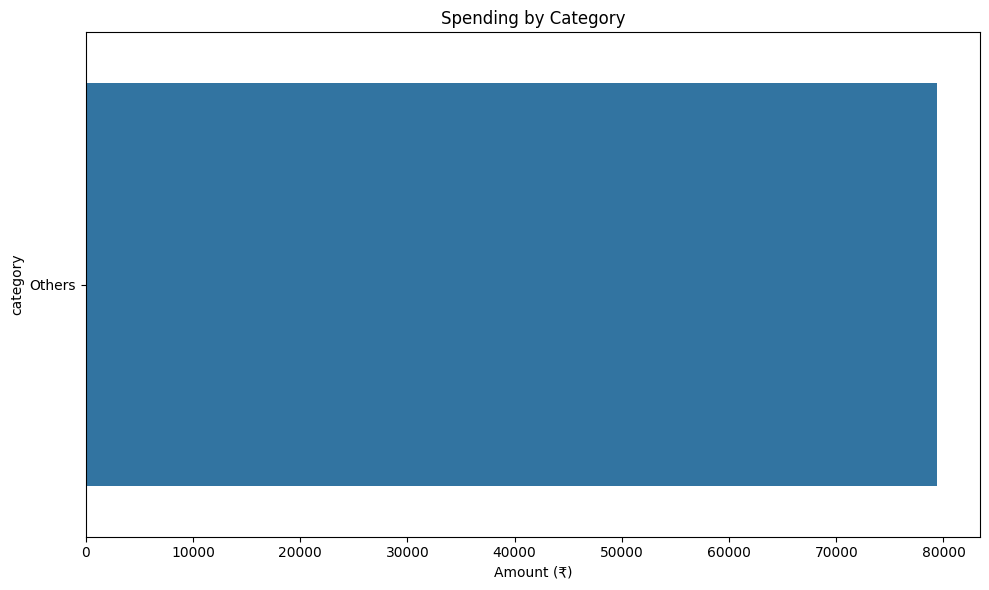

In [85]:
def plot_spending_by_category():
    conn = sqlite3.connect('finance.db')
    df = pd.read_sql_query("""
        SELECT category, SUM(amount) as total 
        FROM transactions 
        WHERE type='debit' 
        GROUP BY category
    """, conn)
    conn.close()
    
    if df.empty:
        print("No transactions yet.")
        return
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='total', y='category')
    plt.title('Spending by Category')
    plt.xlabel('Amount (₹)')
    plt.tight_layout()
    plt.show()

plot_spending_by_category()

In [86]:
def show_transactions():
    """Display all transactions"""
    conn = sqlite3.connect('finance.db')
    df = pd.read_sql_query("SELECT * FROM transactions ORDER BY date DESC", conn)
    conn.close()
    
    if df.empty:
        print("No transactions found yet. Add some using add_transaction()")
    else:
        print(f"Total Transactions: {len(df)}")
        return df  # This will show the table nicely in Jupyter

In [87]:
# RESET EVERYTHING - Clear old biased data
conn = sqlite3.connect('finance.db')
conn.execute("DELETE FROM transactions")
conn.execute("DELETE FROM user_profile")
conn.commit()
conn.close()

print("✅ Database has been reset completely.")

✅ Database has been reset completely.


In [89]:
# 1. Set Salary
set_salary(85000)

# 2. Generate Realistic Data
add_realistic_data(salary=8500, months=6)

# 3. See Your Plan
get_financial_plan()

Profile updated: Monthly Salary = ₹85000
Generating realistic data for ₹8,500 salary...
✅ Added 6 months of realistic low-budget data!
=== 📊 SMART UPI FINANCIAL PLAN ===

Monthly Salary               : ₹85,000.00
Avg Monthly Expenses         : ₹15,268.17
Predicted Next Month Expense : ₹17,182.33

Monthly Surplus              : ₹67,817.67

Recommended Emergency Fund  : ₹91,609.00 (6 months)
   → More realistic for your income level

💰 RECOMMENDED ALLOCATION:
• Emergency Top-up       : ₹16,954
• Investments (SIP/MF)   : ₹33,909
• Buffer Savings         : ₹10,173
• Lifestyle/Fun          : ₹6,782
